<a href="https://colab.research.google.com/github/kuretaru/topo-ml-spin-phases/blob/develop/materials/lessons/3_The_Machine_Learning_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# All the imports

In [13]:
!pip install gudhi

In [14]:
!wget https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/materials/lessons/1_3_dataset/data_x.npy
!wget https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/materials/lessons/1_3_dataset/data_y.npy

--2025-12-15 14:57:59--  https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/materials/lessons/1_3_dataset/data_x.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 720128 (703K) [application/octet-stream]
Saving to: ‘data_x.npy.1’

data_x.npy.1        100%[===================>] 703.25K  --.-KB/s    in 0.007s  

2025-12-15 14:57:59 (101 MB/s) - ‘data_x.npy.1’ saved [720128/720128]

--2025-12-15 14:57:59--  https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/materials/lessons/1_3_dataset/data_y.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP re

In [20]:
import gudhi


from numba import njit
from gudhi.representations import Entropy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


import matplotlib.pyplot as plt
import numpy as np

# Code

Now we just need to put the "stamp of approval" on it using Scikit-Learn. Even though the separation is obvious to our eyes, in Data Science we need a number (Accuracy %) to prove it.

We will use Logistic Regression. It draws a line between the "Low Entropy" and "High Entropy" points.

In [17]:
def get_entropy(lattice):
    # Build Complex
    cc = gudhi.CubicalComplex(dimensions=lattice.shape,
                              top_dimensional_cells=lattice.flatten())
    cc.persistence() # Compute persistence
    intervals = cc.persistence_intervals_in_dimension(1) # Get loops

    if len(intervals) == 0:
        return 0.0

    entropy_calc = Entropy()
    return entropy_calc.fit_transform([intervals])[0][0]

In [18]:
# X_features is the Entropy
# y is the target (0 for Ordered or 1 for Disordered)
X = np.load('data_x.npy')
y = np.load('data_y.npy')

L = 100


print("Calculating entropy for all samples...")

feature_list = [get_entropy(lattice) for lattice in X]

X_features = np.array(feature_list).reshape(-1, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
print("Training the model...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=["Ordered", "Disordered"]))

Calculating entropy for all samples...
Training the model...
Model Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

     Ordered       1.00      1.00      1.00        12
  Disordered       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



Simulating Critical Phase (T=2.3)...


/usr/local/lib/python3.12/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


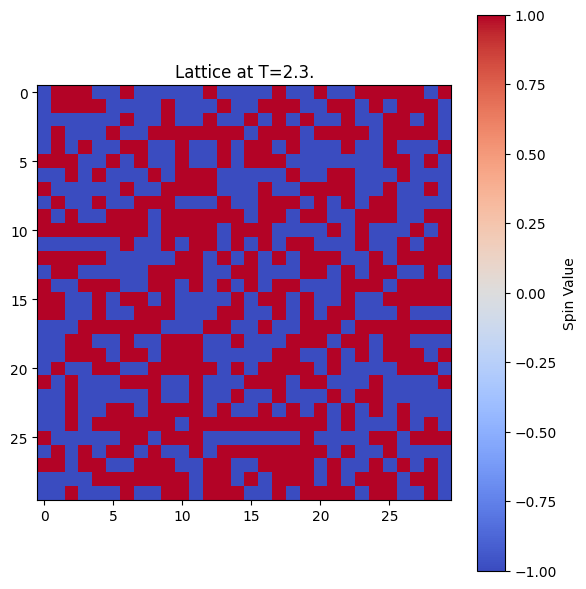

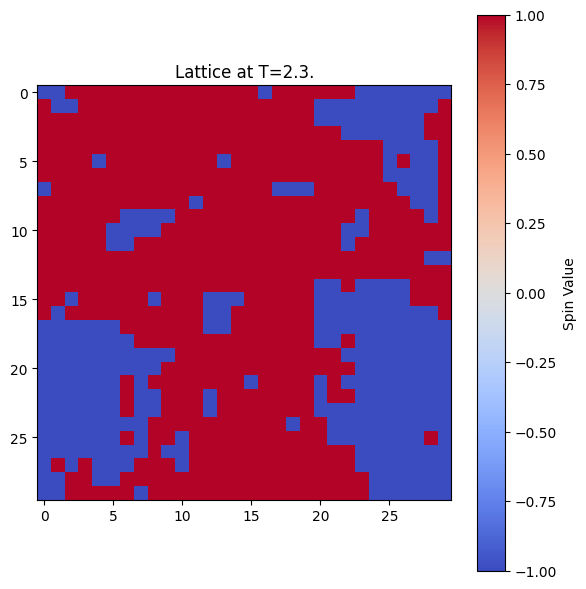

Critical Entropy: 1.7917594692280547
The AI thinks the Critical Point is: Disordered


In [26]:
@njit(nopython=True) # This decorator compiles the function to C-speed
def get_energy_change_fast(lattice, i, j, L):
    spin = lattice[i, j]
    # Periodic Boundary Conditions using modulo operator
    neighbors = lattice[(i+1)%L, j] + lattice[(i-1)%L, j] + \
                lattice[i, (j+1)%L] + lattice[i, (j-1)%L]
    return 2 * spin * neighbors


@njit(nopython=True)
def fast_metropolis(lattice, temperature, num_steps):
    L = lattice.shape[0]
    for _ in range(num_steps):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        dE = get_energy_change_fast(lattice, i, j, L)

        if dE < 0:
            lattice[i, j] *= -1
        elif np.random.rand() < np.exp(-dE / temperature):
            lattice[i, j] *= -1
    return lattice


def generate_simple_lattice(L, temp):
  """
  Generates a simple lattice for the plot.

  Args:
    L (int):      A lattice of the plot.
    temp (float): A temperature.

  Returns: numpy matrix.
  """
  return np.ones((L,L)) if temp < 2 else np.random.choice([-1, 1], (L,L))


def show_plot(L, data, temp):
  """
  Shows a plot for our config.

  Args:
    L (int):            A lattice of the plot.
    data (np.ndarray):  Numpy matrix of current state.
    temp (float):       A temperature.
  """
  plt.figure(figsize=(6,6))
  plt.title(f"Lattice at T={temp}.")

  plt.imshow(data, cmap='coolwarm')
  plt.colorbar(label = 'Spin Value')

  plt.tight_layout()
  plt.show()


def simulate_ising(L, temp, steps):
  """
  Creates a random lattice, runs a sim and finds the final lattice.

  Args:
    L (int):
    temp (float):
    steps (int):

  Raises:
    ValueError: If data type is mismatched.

  Returns: (np.ndarray) numpy matrix
  """
  # Validation start conditions.
  if not isinstance(L, int) or not isinstance(temp, float) or not isinstance(steps, int):
    raise ValueError("Lattice must be an int; Steps must be an int; Temperature must be a float! Aborting...")
  lattice = generate_simple_lattice(L, temp)
  show_plot(L, lattice, temp)
  lattice = fast_metropolis(lattice, temp, steps)
  show_plot(L, lattice, temp)
  return lattice


if __name__ == "__main__":
  print("Simulating Critical Phase (T=2.3)...")
  critical_lattice = simulate_ising(30, 2.3, 1_000_000)

  crit_entropy = get_entropy(critical_lattice)
  print(f"Critical Entropy: {crit_entropy}")

  prediction = model.predict([[crit_entropy]])
  label = "Disordered" if prediction[0] == 1 else "Ordered"

  print(f"The AI thinks the Critical Point is: {label}")